# 黑洞标量场散射截面计算

## Part 1: Schwarzschild 黑洞验证

使用 Schwarzschild 度规 ($A = 1-1/r$, $B = 1/A$, $r_h = 1$) 验证散射计算代码的正确性。

验证指标：
1. S-matrix 各分波 $|S_l| \approx 1$（幺正性）
2. 微分散射截面图形合理（前向散射增强，衍射振荡）

**注**：$\mu=0$ 为无质量标量场，$\mu \neq 0$ 为有质量场，要求 $\omega > \mu$。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scattering import schwarzschild_scattering

# ── Schwarzschild 验证参数 ──
omega = 5
lmax = 50
epsilon = 1e-5
mu = 0.1        # 场质量（0 为无质量标量场）

result = schwarzschild_scattering(omega=omega, lmax=lmax, epsilon=epsilon, mu=mu)

# ── 幺正性检查：|S_l| 应接近 1 ──
abs_S = result.unitarity_check()
print("l\t|S_l|")
for l in range(lmax + 1):
    print(f"{l}\t{abs_S[l]:.8f}")

计算乌龟坐标...
  求解 l = 0/50 ...
  求解 l = 10/50 ...
  求解 l = 20/50 ...
  求解 l = 30/50 ...
  求解 l = 40/50 ...
  求解 l = 50/50 ...
S-matrix 幺正性: |S_l| in [0.000000, 1.000000]
计算微分散射截面...
完成！
l	|S_l|
0	0.00000034
1	0.00000053
2	0.00000087
3	0.00000123
4	0.00000200
5	0.00000320
6	0.00000415
7	0.00000580
8	0.00000597
9	0.00001925
10	0.00050926
11	0.01022507
12	0.21509896
13	0.98127168
14	0.99996838
15	0.99999995
16	1.00000000
17	1.00000000
18	1.00000000
19	1.00000000
20	1.00000000
21	1.00000000
22	1.00000000
23	1.00000000
24	1.00000000
25	1.00000000
26	1.00000000
27	1.00000000
28	1.00000000
29	1.00000000
30	1.00000000
31	1.00000000
32	1.00000000
33	1.00000000
34	1.00000000
35	1.00000000
36	1.00000000
37	1.00000000
38	1.00000000
39	1.00000000
40	1.00000000
41	1.00000000
42	1.00000000
43	1.00000000
44	1.00000000
45	1.00000000
46	1.00000000
47	1.00000000
48	1.00000000
49	1.00000000
50	1.00000000


已保存 PDF: scattering_schwarzschild_w5.pdf


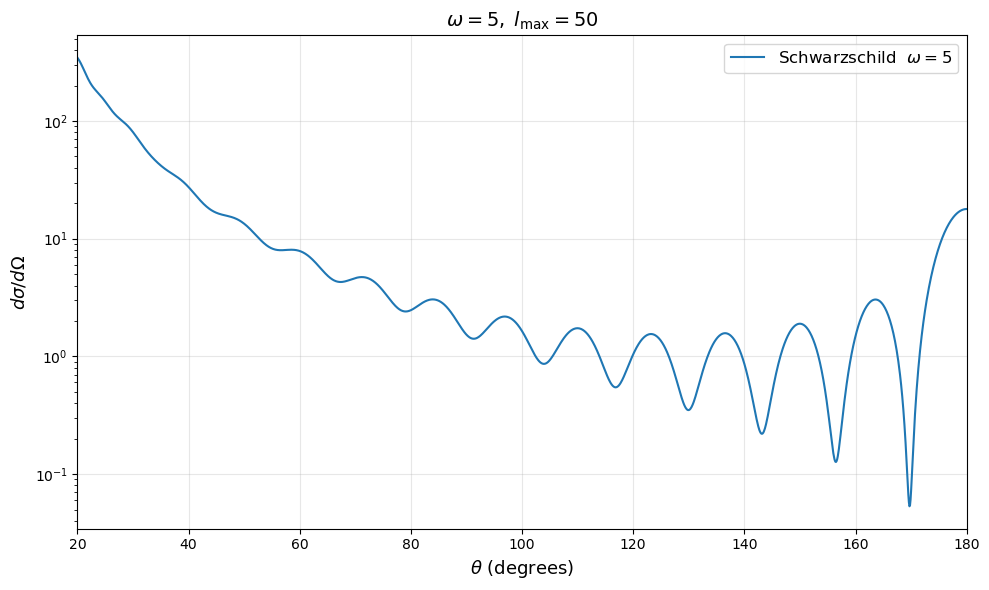

In [2]:
# ── 微分散射截面图 ──
fig, ax = plt.subplots(figsize=(10, 6))
result.plot(ax=ax, label=f'Schwarzschild  $\\omega={omega}$')
ax.legend(fontsize=12)
plt.tight_layout()
pdf_path = f'scattering_schwarzschild_w{omega}.pdf'
fig.savefig(pdf_path, format='pdf', bbox_inches='tight')
print(f'已保存 PDF: {pdf_path}')
plt.show()

## Part 2: EsGB 黑洞散射

调用 `esgb_solver_core.py` 求解 EsGB 黑洞度规，然后计算其散射截面并与 Schwarzschild 对比。

In [3]:
import esgb_solver_core as esgb
from scipy.interpolate import CubicSpline
from scattering import compute_scattering

# ── 求解 EsGB 黑洞 ──
rh = 1.0
alpha = 0.3
beta = -0.6
phi_h_init = 0.82

sol = esgb.solve(rh=rh, alpha=alpha, beta=beta,
                 phi_h_init=phi_h_init, N=13, verbose=True)
print(sol)

[OK]  alpha=0.3, beta=-0.6, phi_h=0.91466, M=0.68136, Q=2.01746, ||R||=3.86e-10
EsGBSolution(converged, alpha=0.3, beta=-0.6, phi_h=0.9147, M=0.6814, Q=2.0175, ||R||=3.86e-10)


In [4]:
# ── 用 EsGBSolution 的谱插值方法构建度规函数 ──
# gtt(r) = A(r)，grr(r) = B(r)
A_esgb  = sol.gtt_at      # A(r)
B_esgb  = sol.grr_at      # B(r)
dA_esgb = sol.dgtt_dr     # A'(r)
dB_esgb = sol.dgrr_dr     # B'(r)

# ── 散射计算 ──
omega = 5
lmax = 50
mu = 0.0        # 场质量（与 Part 1 保持一致）

result_esgb = compute_scattering(
    A_esgb, B_esgb, dA_esgb, dB_esgb,
    omega=omega, lmax=lmax, r_horizon=rh,
    epsilon=1e-5, mu=mu
)

# 幺正性检查
abs_S = result_esgb.unitarity_check()
print("EsGB |S_l| 范围:", f"[{abs_S.min():.8f}, {abs_S.max():.8f}]")

计算乌龟坐标...
  求解 l = 0/50 ...
  求解 l = 10/50 ...
  求解 l = 20/50 ...
  求解 l = 30/50 ...
  求解 l = 40/50 ...
  求解 l = 50/50 ...
S-matrix 幺正性: |S_l| in [0.000000, 1.000000]
计算微分散射截面...
完成！
EsGB |S_l| 范围: [0.00000025, 1.00000000]


已保存 PDF: scattering_comparison_w5_alpha0.3_beta-0.6.pdf


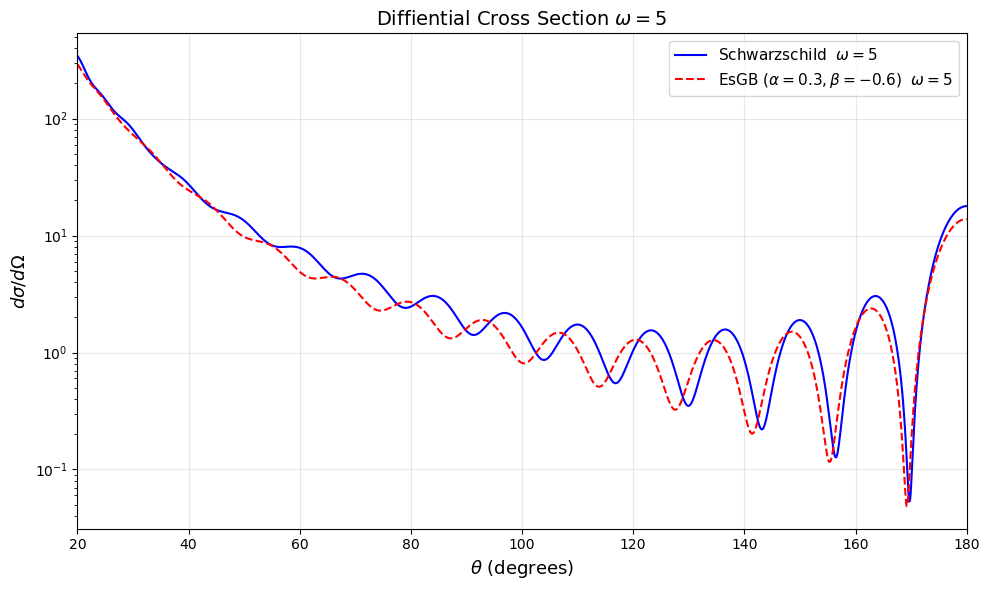

In [5]:
# ── 对比图：EsGB vs Schwarzschild ──
fig, ax = plt.subplots(figsize=(10, 6))
result.plot(ax=ax, label=f'Schwarzschild  $\\omega={omega}$', color='blue')
result_esgb.plot(ax=ax, label=f'EsGB ($\\alpha={alpha},\\beta={beta}$)  $\\omega={omega}$',
                 color='red', linestyle='--')
ax.legend(fontsize=11)
ax.set_title(rf'Diffiential Cross Section $\omega={omega}$', fontsize=14)
plt.tight_layout()
pdf_path = f'scattering_comparison_w{omega}_alpha{alpha}_beta{beta}.pdf'
fig.savefig(pdf_path, format='pdf', bbox_inches='tight')
print(f'已保存 PDF: {pdf_path}')
plt.show()